# Colocalization: do two channels report on the same structures?

Two colours, one image, one question — and at least two different ways to answer
it, because *colocalization* means different things for continuous distributions
and for discrete particles.

This notebook walks through both regimes on synthetic data whose answer we know
by construction, so every number can be checked against what went in:

1. **pixel-wise coefficients** — Pearson, Manders, Costes, Li, Spearman;
2. **is it more than chance?** — Costes' randomization test;
3. **are the channels even registered?** — van Steensel's profile and the 2-D plane;
4. **object-based colocalization** — for punctate signal, where the coefficients
   answer the wrong question.

The theory behind each coefficient is in the ChiSurf documentation
(*Concepts → Colocalization*); the GUI workflow is *Guides → Two-channel
colocalization*.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from chisurf.core.fluorescence.imaging import (
    colocalization_metrics,
    costes_significance,
    costes_threshold,
    cross_correlation_2d,
    object_colocalization,
    object_distance_histogram,
    pearson,
    pearson_profile,
    van_steensel,
)

SHAPE = (160, 160)
rng = np.random.default_rng(2026)
Y, X = np.mgrid[: SHAPE[0], : SHAPE[1]]


def blobs(centres, sigma=6.0, amplitude=120.0):
    """Return an image with Gaussian spots at *centres*."""
    image = np.zeros(SHAPE, dtype=float)
    for cy, cx in centres:
        image += amplitude * np.exp(-((Y - cy) ** 2 + (X - cx) ** 2) / (2 * sigma**2))
    return image

## 1. A continuous pair

Channel B follows channel A at 80 % brightness, both sit on a background of 8
counts, and both carry shot-like noise. This is the regime the intensity
coefficients were made for.

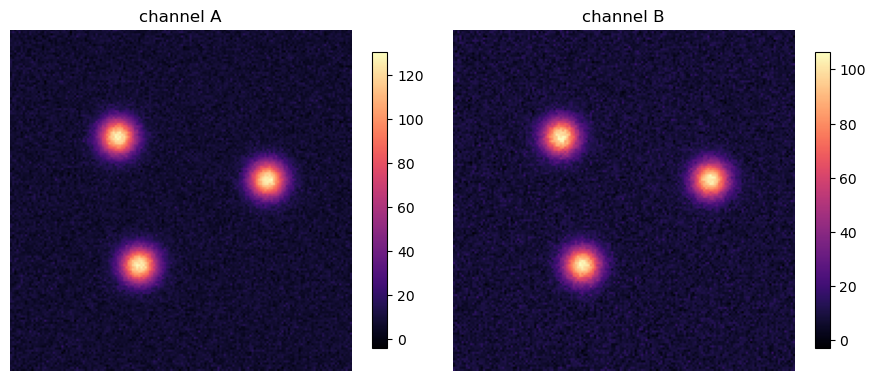

In [2]:
structure = blobs([(50, 50), (110, 60), (70, 120)])
background = 8.0
channel_a = structure + background + rng.normal(0.0, 3.0, SHAPE)
channel_b = 0.8 * structure + background + rng.normal(0.0, 3.0, SHAPE)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, image, title in zip(axes, (channel_a, channel_b), ("channel A", "channel B")):
    im = ax.imshow(image, cmap="magma")
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()

### Background and thresholds

Every coefficient is computed on background-subtracted data, and most of them
only on pixels above a threshold. Choosing that threshold by eye is the single
largest reason published colocalization numbers cannot be compared — so let
**Costes' method** derive it: walk an orthogonal regression line downwards until
the pixels below it stop correlating.

In [3]:
costes = costes_threshold(channel_a - background, channel_b - background)
print(f"orthogonal fit : B = {costes['slope']:.2f}·A + {costes['intercept']:.2f}")
print(f"thresholds     : A > {costes['threshold_a']:.2f}, B > {costes['threshold_b']:.2f}")

orthogonal fit : B = 0.80·A + -0.02
thresholds     : A > 2.66, B > 2.11


### The coefficients

Each answers a different question, which is why they are reported together:

| coefficient | question |
|---|---|
| Pearson PCC | do the intensities *co-vary*? |
| Manders MOC | do the signals *co-occur*? |
| Manders M1 / M2 | how much of A is with B — and of B with A? |
| Li ICQ | do both deviate from their means in the same direction? |
| Spearman | is the relation monotonic, even if not linear? |

In [4]:
result = colocalization_metrics(
    channel_a,
    channel_b,
    background_a=background,
    background_b=background,
    auto_threshold=True,
    profiles=True,
    ccf_max_shift=12,
    ccf_2d=True,
)
metrics = result.metrics
for key in ("pearson", "manders_overlap", "manders_m1", "manders_m2", "li_icq", "spearman"):
    print(f"{key:18s}: {metrics[key]: .3f}")

pearson           :  0.991
manders_overlap   :  0.995
manders_m1        :  0.971
manders_m2        :  0.979
li_icq            :  0.472
spearman          :  0.889


### The scatter plot is the raw data

All those numbers are summaries of one 2-D object: the joint histogram.
Colocalized structures form a tilted cloud through the origin; segregated ones
sit along the axes.

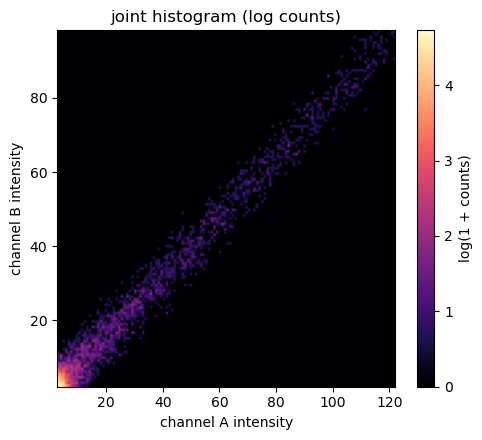

In [5]:
histogram = result.histogram
plt.figure(figsize=(5, 4.5))
plt.imshow(
    np.log1p(histogram["histogram"]).T,
    origin="lower",
    aspect="auto",
    cmap="magma",
    extent=[
        histogram["edges_a"][0],
        histogram["edges_a"][-1],
        histogram["edges_b"][0],
        histogram["edges_b"][-1],
    ],
)
plt.xlabel("channel A intensity")
plt.ylabel("channel B intensity")
plt.title("joint histogram (log counts)")
plt.colorbar(label="log(1 + counts)")
plt.tight_layout()

## 2. Is it more than chance?

Two dense stainings correlate because both fill the cell. The **Costes
randomization test** measures that baseline: one channel is scrambled in
PSF-sized blocks — destroying any real spatial relation while keeping the
intensity distribution *and* the local texture — and the measured PCC is
compared against the resulting null distribution.

Colocalization is conventionally called significant at *p* > 0.95.

In [6]:
significance = costes_significance(
    channel_a - background, channel_b - background, block=4, n_randomizations=200, seed=0
)
print(f"observed PCC   : {significance['r_observed']:.3f}")
print(f"random PCC     : {significance['r_random_mean']:.3f} ± {significance['r_random_std']:.3f}")
print(f"p-value        : {significance['p_value']:.3f}")

# The same test on two independent noise images — the control that must fail.
noise = costes_significance(
    rng.normal(size=SHAPE), rng.normal(size=SHAPE), block=4, n_randomizations=200, seed=0
)
print(f"control p-value: {noise['p_value']:.3f}")

observed PCC   : 0.940
random PCC     : -0.000 ± 0.024
p-value        : 1.000


control p-value: 0.160


## 3. Are the channels registered?

Chromatic aberration shifts one channel by a fraction of a micrometre — enough
to destroy a real colocalization or, with periodic structures, to fabricate one.
Shift one channel and recompute the correlation at every offset: the peak
position *is* the registration error.

The 1-D profile only scans horizontally, so a purely **vertical** offset leaves
it peaking at zero and looking perfectly registered. The 2-D plane does not have
that blind spot.

1-D peak: 0 px — the horizontal profile sees nothing
2-D peak: dx=0, dy=4 px — the real offset
diagonal : dx=-3, dy=4 px (rolled 4 down, 3 left)


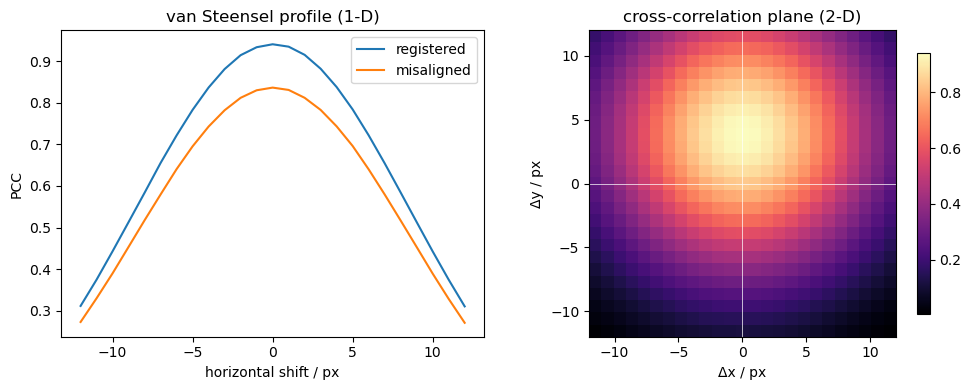

In [7]:
misaligned = np.roll(channel_b, 4, axis=0)  # 4 px down — purely vertical

profile_ok = van_steensel(channel_a, channel_b, max_shift=12)
profile_bad = van_steensel(channel_a, misaligned, max_shift=12)
plane_bad = cross_correlation_2d(channel_a, misaligned, max_shift=12)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(profile_ok["shift"], profile_ok["ccf"], label="registered")
axes[0].plot(profile_bad["shift"], profile_bad["ccf"], label="misaligned")
axes[0].set_xlabel("horizontal shift / px")
axes[0].set_ylabel("PCC")
axes[0].legend()
axes[0].set_title("van Steensel profile (1-D)")

im = axes[1].imshow(
    plane_bad["map"],
    origin="lower",
    cmap="magma",
    extent=[plane_bad["dx"][0], plane_bad["dx"][-1], plane_bad["dy"][0], plane_bad["dy"][-1]],
)
axes[1].axhline(0, color="w", lw=0.5)
axes[1].axvline(0, color="w", lw=0.5)
axes[1].set_xlabel("Δx / px")
axes[1].set_ylabel("Δy / px")
axes[1].set_title("cross-correlation plane (2-D)")
fig.colorbar(im, ax=axes[1], shrink=0.85)
fig.tight_layout()

print(f"1-D peak: {profile_bad['peak_shift']} px — the horizontal profile sees nothing")
print(f"2-D peak: dx={plane_bad['peak_dx']}, dy={plane_bad['peak_dy']} px — the real offset")

# A diagonal offset is recovered in both coordinates at once.
diagonal = cross_correlation_2d(channel_a, np.roll(channel_b, (4, -3), axis=(0, 1)), max_shift=12)
print(f"diagonal : dx={diagonal['peak_dx']}, dy={diagonal['peak_dy']} px (rolled 4 down, 3 left)")

## 4. Where does the correlation live?

One coefficient averages over every pixel. Binning by brightness and computing
PCC inside each bin shows *where* the correlation comes from: rising with
intensity means real structures on an uncorrelated background, collapsing at the
top means a saturating detector.

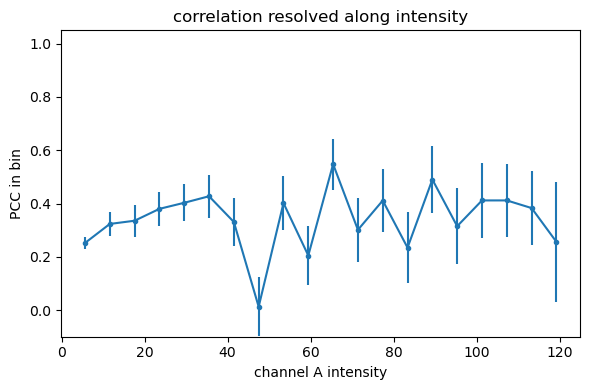

In [8]:
profile = pearson_profile(
    (channel_a - background)[result.mask], (channel_b - background)[result.mask], bins=20
)
plt.figure(figsize=(6, 4))
plt.errorbar(profile["x"], profile["pearson"], yerr=profile["error"], marker="o", ms=3)
plt.xlabel("channel A intensity")
plt.ylabel("PCC in bin")
plt.ylim(-0.1, 1.05)
plt.title("correlation resolved along intensity")
plt.tight_layout()

## 5. Punctate signal: count objects instead

For discrete spots the coefficients above answer the wrong question. Sparse
puncta sit mostly on empty background, so the correlation is dominated by the
co-occurrence of *nothing* — a Pearson coefficient can be mediocre for perfectly
coincident spots.

Here 30 spots in channel A, of which **20** have a partner 1 px away in B, plus 5
spots in B that belong to nobody. The object analysis should recover exactly that.

In [9]:
centres = [tuple(p) for p in rng.integers(12, 148, size=(30, 2))]
partners = [(cy + 1, cx) for cy, cx in centres[:20]]
strangers = [tuple(p) for p in rng.integers(12, 148, size=(5, 2))]
puncta_a = blobs(centres, sigma=2.2) + rng.normal(0.0, 2.0, SHAPE)
puncta_b = blobs(partners + strangers, sigma=2.2) + rng.normal(0.0, 2.0, SHAPE)

objects = object_colocalization(puncta_a, puncta_b, distance=3.0, min_size=4)
object_metrics = objects["metrics"]

print(f"Pearson PCC on puncta      : {pearson(puncta_a, puncta_b):.3f}   ← the wrong question")
print(f"objects found (A / B)      : {object_metrics['n_objects_a']} / {object_metrics['n_objects_b']}")
print(f"fraction of A with partner : {object_metrics['object_fraction_a_near_b']:.2f}  (built in: 20/30 = 0.67)")
print(f"fraction of B with partner : {object_metrics['object_fraction_b_near_a']:.2f}")
print(f"median distance A → B      : {object_metrics['object_median_distance_a']:.2f} px  (built in: 1)")

Pearson PCC on puncta      : 0.669   ← the wrong question
objects found (A / B)      : 27 / 22
fraction of A with partner : 0.63  (built in: 20/30 = 0.67)
fraction of B with partner : 0.77
median distance A → B      : 1.03 px  (built in: 1)


The **tolerance** is the one honest parameter: two objects cannot be localised
better than the PSF, so "coincident" means "closer than the resolution", not
"identical centroid".

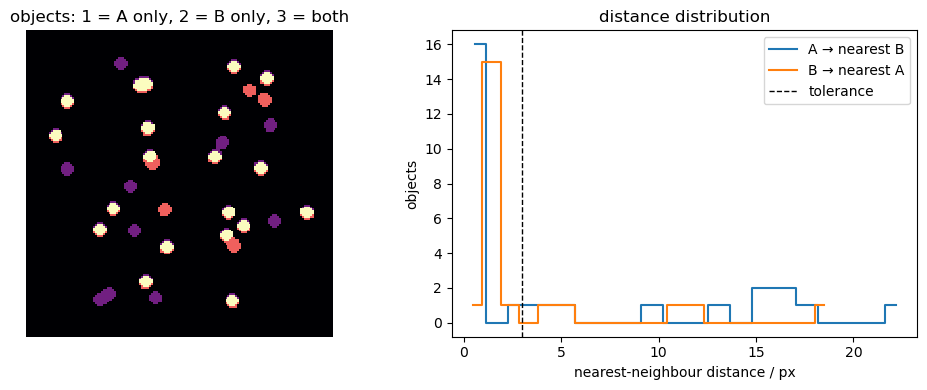

In [10]:
mask_a = objects["objects_a"].mask
mask_b = objects["objects_b"].mask
category = mask_a.astype(int) + 2 * mask_b.astype(int)  # 1 = A, 2 = B, 3 = both

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(category, cmap="magma", interpolation="nearest")
axes[0].set_title("objects: 1 = A only, 2 = B only, 3 = both")
axes[0].set_axis_off()

for key, label in (("distances_a", "A → nearest B"), ("distances_b", "B → nearest A")):
    histogram = object_distance_histogram(objects[key], bins=20)
    axes[1].step(histogram["x"], histogram["counts"], where="mid", label=label)
axes[1].axvline(3.0, color="k", ls="--", lw=1, label="tolerance")
axes[1].set_xlabel("nearest-neighbour distance / px")
axes[1].set_ylabel("objects")
axes[1].legend()
axes[1].set_title("distance distribution")
fig.tight_layout()

The spike at ~1 px is the real partners; the flat tail is what chance looks like
— objects whose "nearest neighbour" is just the closest unrelated spot.

## What to report

A defensible colocalization result is not one number:

* **PCC**, and **M1/M2** for the asymmetry PCC cannot express;
* the **thresholds** and how they were chosen (ideally Costes);
* the **Costes p-value** with its block size;
* the **registration** check (2-D peak at 0, 0);
* for puncta: object **counts**, the **coincident fraction** *and* the tolerance.

All of it is available headlessly — `img-coloc IMAGE.ptu -a green -b red
--auto-background --costes-threshold --costes-test --objects --json` — and in the
GUI under *Imaging → Colocalization*.